<a href="https://colab.research.google.com/github/replysantosh-lang/ECARDeepLearning/blob/main/DAY03/Basic_Convolutional_Network_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**steps_per_epoch = 50
epochs = 30**

Found 3598 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 365s 7s/step - acc: 0.5138 - loss: 0.6941 - val_acc: 0.5075 - val_loss: 0.6929
Epoch 2/30
 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.4062 - loss: 0.6997

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


 7/50 ━━━━━━━━━━━━━━━━━━━━ 1:49 3s/step - acc: 0.5006 - loss: 0.6941

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


50/50 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - acc: 0.5329 - loss: 0.6879 - val_acc: 0.5275 - val_loss: 0.6816
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 471ms/step - acc: 0.5553 - loss: 0.6809 - val_acc: 0.5775 - val_loss: 0.6788
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - acc: 0.5506 - loss: 0.6829 - val_acc: 0.5500 - val_loss: 0.6728
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - acc: 0.5825 - loss: 0.6707 - val_acc: 0.5000 - val_loss: 0.7656
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - acc: 0.5721 - loss: 0.6664 - val_acc: 0.5100 - val_loss: 0.7199
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 826ms/step - acc: 0.5746 - loss: 0.6687 - val_acc: 0.6175 - val_loss: 0.6592
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 543ms/step - acc: 0.5850 - loss: 0.6679 - val_acc: 0.6300 - val_loss: 0.6550
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - acc: 0.5817 - loss: 0.6783 - val_acc: 0.6200 - val_loss: 0.6550
Epoch 10/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 466ms/step - acc: 0.6012 - 

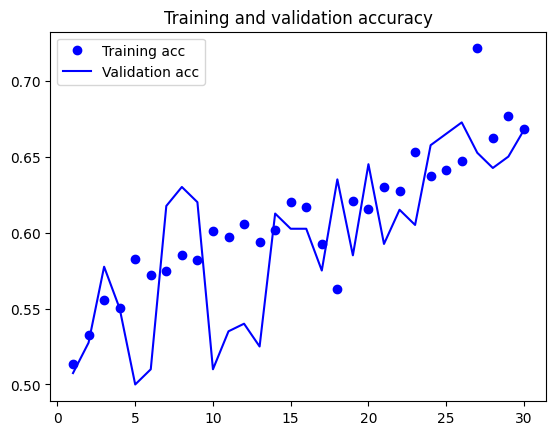

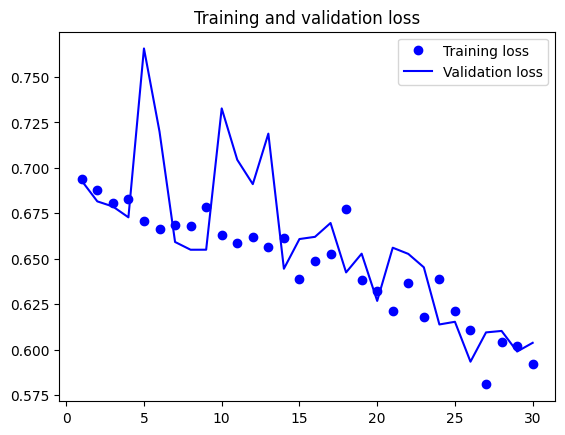

In [37]:
#Keras Model with Image Augmentation and Dropout to reduce overfitting
from keras import layers
from keras import models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir="/content/drive/MyDrive/cats_dogs_dataset/cats_dogs_dataset/train/"
validation_dir="/content/drive/MyDrive/cats_dogs_dataset/cats_dogs_dataset/validation/"

train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=40,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,)

#Validation Data Set should not be augmented
test_datagen = ImageDataGenerator(rescale=1./255)
#Resize all images to 150x150
train_generator = train_datagen.flow_from_directory(train_dir,target_size=(150, 150),batch_size=32,class_mode='binary')
validation_generator = test_datagen.flow_from_directory(
validation_dir,target_size=(150, 150),batch_size=32,class_mode='binary')
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

from keras import optimizers
model.compile(loss='binary_crossentropy',optimizer=optimizers.RMSprop(learning_rate=1e-4),metrics=['acc'])

history = model.fit(
train_generator,
#steps_per_epoch=100,
steps_per_epoch=50,
#epochs=100,
epochs=30,
validation_data=validation_generator,
validation_steps=50)

model.save('cats_and_dogs_small_2.h5')

import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

**Changing
steps_per_epoch= 50 to 100
epochs= 30 to 100**

Found 3598 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 384ms/step - acc: 0.5207 - loss: 0.6925 - val_acc: 0.5200 - val_loss: 0.6908
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - acc: 0.5240 - loss: 0.6881 - val_acc: 0.6025 - val_loss: 0.6821
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 339ms/step - acc: 0.5613 - loss: 0.6811 - val_acc: 0.6050 - val_loss: 0.6724
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - acc: 0.5721 - loss: 0.6743 - val_acc: 0.5875 - val_loss: 0.6739
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 331ms/step - acc: 0.5921 - loss: 0.6695 - val_acc: 0.6150 - val_loss: 0.6663
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - acc: 0.5769 - loss: 0.6606 - val_acc: 0.5725 - val_loss: 0.6662
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 324ms/step - acc: 0.6053 - loss: 0.6621 - val_acc: 0.6100 - val_loss: 0.6557
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - acc: 0.5962 -

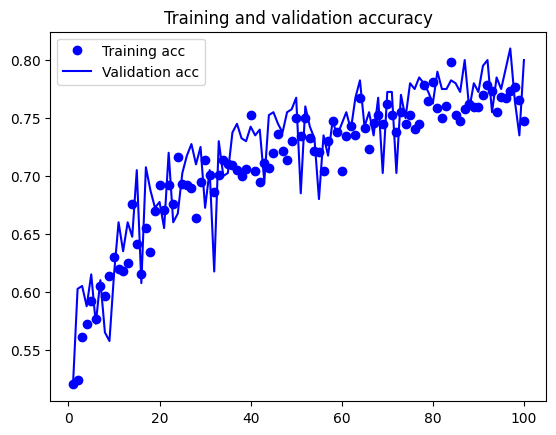

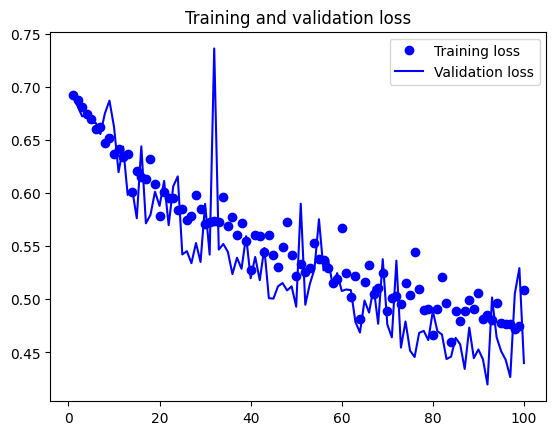

In [38]:
#Keras Model with Image Augmentation and Dropout to reduce overfitting
from keras import layers
from keras import models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir="/content/drive/MyDrive/cats_dogs_dataset/cats_dogs_dataset/train/"
validation_dir="/content/drive/MyDrive/cats_dogs_dataset/cats_dogs_dataset/validation/"

train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=40,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,)

#Validation Data Set should not be augmented
test_datagen = ImageDataGenerator(rescale=1./255)
#Resize all images to 150x150
train_generator = train_datagen.flow_from_directory(train_dir,target_size=(150, 150),batch_size=32,class_mode='binary')
validation_generator = test_datagen.flow_from_directory(
validation_dir,target_size=(150, 150),batch_size=32,class_mode='binary')
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

from keras import optimizers
model.compile(loss='binary_crossentropy',optimizer=optimizers.RMSprop(learning_rate=1e-4),metrics=['acc'])

history = model.fit(
train_generator,
steps_per_epoch=100,
epochs=100,
validation_data=validation_generator,
validation_steps=50)

model.save('cats_and_dogs_small_2.h5')

import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()